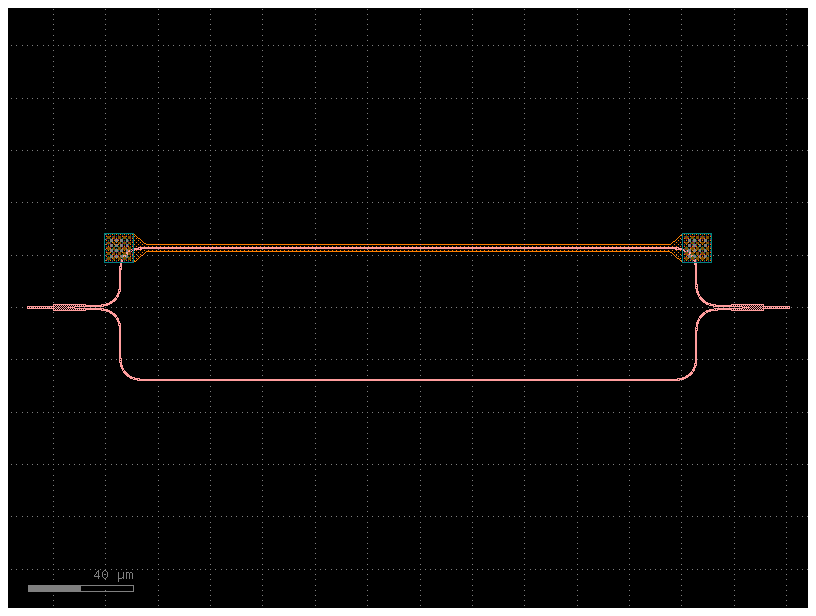

In [1]:
import gdsfactory as gf
import matplotlib.pyplot as plt
import numpy as np

import sax

delta_length = 10
mzi_component = gf.components.mzi_phase_shifter_top_heater_metal(
    delta_length=delta_length
)
fig = mzi_component.plot()

In [2]:

def straight(wl=1.5, length=10.0, neff=2.4):
    wl0 = 1.5  # center wavelength for which the waveguide model is defined
    return sax.reciprocal({("o1", "o2"): np.exp(2j * np.pi * neff * length / wl)})


def mmi1x2():
    """Returns a perfect 1x2 splitter."""
    return sax.reciprocal(
        {
            ("o1", "o2"): 0.5**0.5,
            ("o1", "o3"): 0.5**0.5,
        }
    )


def bend_euler(wl=1.5, length=20.0):
    """Returns bend Sparameters with reduced transmission compared to a straight."""
    return {k: 0.99 * v for k, v in straight(wl=wl, length=length).items()}


class phase_shifter_heater_builder:
    def __init__(self):
        # state initialization
        self.time_state = 0

    def __call__(
        self,
        wl: float = 1.55,
        neff: float = 2.34,
        length: float = 10,
        loss: float = 0.0,
        voltage: float = 0.0,
        time: float = 0.0,
    ):
        """Returns simple phase shifter model"""
        assert time >= self.time_state, f"Time must be greater than {self.time_state}"

        deltaphi = voltage * np.pi
        phase = 2 * np.pi * neff * length / wl + deltaphi
        amplitude = np.asarray(10 ** (-loss * length / 20), dtype=complex)
        transmission = amplitude * np.exp(1j * phase)
        sdict = sax.reciprocal(
            {
                ("o1", "o2"): transmission,
            }
        )

        self.time_state = time
        print(f"sim_time={self.time_state}")

        return sdict


def create_phase_shifter_heater_model() -> sax.Model:
    return phase_shifter_heater_builder()


assert sax.is_model_factory(create_phase_shifter_heater_model)

sim_time=0.0
sim_time=0.1


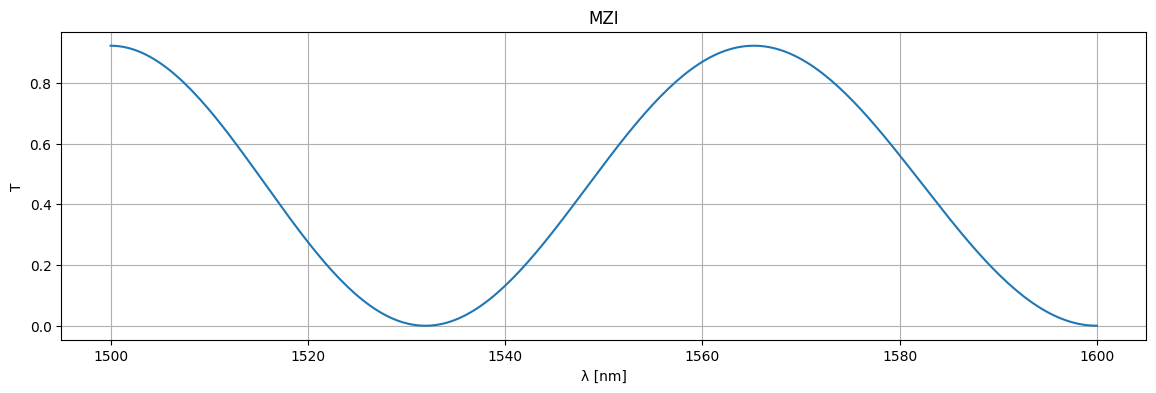

sim_time=0.1
sim_time=0.2
sim_time=0.30000000000000004
sim_time=0.4
sim_time=0.5


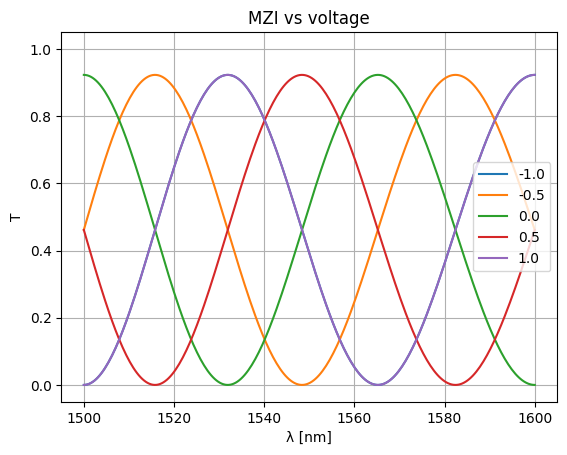

In [3]:
models = {
    "bend_euler": bend_euler,
    "mmi1x2": mmi1x2,
    "straight": straight,
    "straight_heater_metal_undercut": create_phase_shifter_heater_model,
}

mzi_component = gf.components.mzi_phase_shifter_top_heater_metal(
    delta_length=delta_length,
)
netlist = mzi_component.get_netlist()
mzi_circuit, cir_info = sax.circuit(
    netlist=netlist,
    models=models,
    ignore_missing_ports=True,
)

wl = np.linspace(1.5, 1.6, 256)
S = mzi_circuit(wl=wl, time=0.1)

plt.figure(figsize=(14, 4))
plt.title("MZI")
plt.plot(1e3 * wl, np.abs(S["o1", "o2"]) ** 2)  # type: ignore
plt.xlabel("λ [nm]")
plt.ylabel("T")
plt.grid(True)
plt.show()

voltages = np.linspace(-1, 1, num=5)

for i, voltage in enumerate(voltages):
    S = mzi_circuit(
        wl=wl,
        time=0.1 * (i + 1),
        sxt={"voltage": voltage},
    )
    plt.plot(wl * 1e3, abs(S["o1", "o2"]) ** 2, label=str(voltage))  # type: ignore
    plt.xlabel("λ [nm]")
    plt.ylabel("T")
    plt.ylim(-0.05, 1.05)
    plt.grid(True)

plt.title("MZI vs voltage")
plt.legend()
plt.show()
